# FEM for submerged tunnel as 3D beams

In [159]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

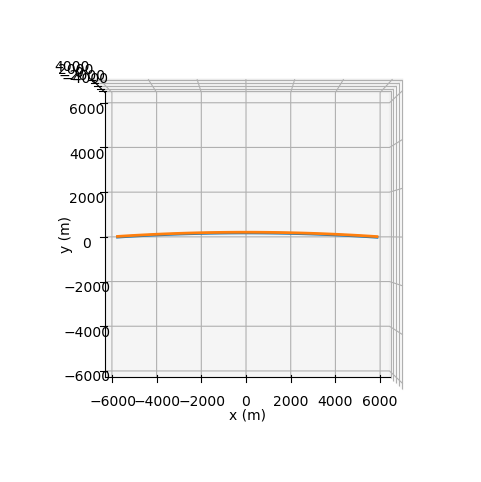

In [160]:
TunRad = 84118 #m
TunAng = (90+7.5/2, 90-7.5/2) #deg
# dth = 0.0307 #deg
dth = 7.5/100
TunCX = TunRad*np.cos( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunRad*np.sin( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunCY - min(TunCY)-15
TunCZ = 0*TunCX

TunCX2 = TunRad*np.cos( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY2 = TunRad*np.sin( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY2 = TunCY2 - min(TunCY2)+15
TunCZ2 = 0*TunCX2

ax = plt.axes(projection='3d')
ax.view_init(90, 270)
plt.plot(TunCX, TunCY, TunCZ, lw=2)
plt.plot(TunCX2, TunCY2, TunCZ2, lw=2)
plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')


TunCX = np.append(TunCX, TunCX2)
TunCY = np.append(TunCY, TunCY2)
TunCZ = np.append(TunCZ, TunCZ2)

## Properties of Beam

In [161]:
Beam_GJ = 2.12e13                 # [N.m2]
Beam_Im = 1.17e6                      #[kg.m]
Beam_m = 248609                  # [kg/m]
Beam_EIy = 141193e9               # [N.m2]
Beam_EIz = 141193e9               # [N.m2]
Beam_EA = 2*15.46*55*10**6       # [N]

connector_GJ = 2.12e13 / 2                 # [N.m2]
connector_Im = 1.17e6 / 2                     #[kg.m]
connector_m = 248609 / 2               # [kg/m]
connector_EIy = 141193e9 / 2               # [N.m2]
connector_EIz = 141193e9 / 2                   # [N.m2]
connector_EA = (6 * 5 - 5.5 * 4.5) * 39e9     # [N]



print("Torsional rigidity (GJ) "f"{Beam_GJ:.2}"" N.m2")
print("Mass moment of inertia (Im) "f"{Beam_Im:.2}"" kg.m")
print("Mass per meter "f"{Beam_m}"" kg/m")
print("Flexural rigidity (EI_y) "f"{Beam_EIy:.2}"" N.m2")
print("Flexural rigidity (EI_z) "f"{Beam_EIz:.2}"" N.m2")
print("Axial rigidity (EA)" f"{Beam_EA:.2}" " N")

print("-" * 50)

print("Torsional rigidity connector (GJ) "f"{connector_GJ:.2}"" N.m2")
print("Mass moment of inertia connector (Im) "f"{connector_Im:.2}"" kg.m")
print("Mass per meter connector "f"{connector_m}"" kg/m")
print("Flexural rigidity connector (EI_y) "f"{connector_EIy:.2}"" N.m2")
print("Flexural rigidity connector (EI_z) "f"{connector_EIz:.2}"" N.m2")
print("Axial rigidity connector (EA)" f"{connector_EA:.2}" " N")



# Beam_m = 1.28e5                  # [kg/m]
# Beam_EI_y = 1.89e13                 # [N.m2]
# Beam_EI_z = 1.89e13                 # [N.m2]
# Beam_EA = 1.08e12                 # [N]
# Beam_GJ = 1.45e13                 # [N.m2]
# Beam_Im = 30                      #[kg.m]

Torsional rigidity (GJ) 2.1e+13 N.m2
Mass moment of inertia (Im) 1.2e+06 kg.m
Mass per meter 248609 kg/m
Flexural rigidity (EI_y) 1.4e+14 N.m2
Flexural rigidity (EI_z) 1.4e+14 N.m2
Axial rigidity (EA)1.7e+09 N
--------------------------------------------------
Torsional rigidity connector (GJ) 1.1e+13 N.m2
Mass moment of inertia connector (Im) 5.8e+05 kg.m
Mass per meter connector 124304.5 kg/m
Flexural rigidity connector (EI_y) 7.1e+13 N.m2
Flexural rigidity connector (EI_z) 7.1e+13 N.m2
Axial rigidity connector (EA)2e+11 N


## Mesh setup

In [162]:
# -----------------------------
# Nodes
# -----------------------------
NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]
nNode = len(NodeC)

nodeDiff = int(round(nNode / 2))

if nNode != 2 * nodeDiff:
    raise ValueError("The model expects the two tunnel tubes to have the same number of nodes.")

# -----------------------------
# Tunnel elements
# -----------------------------
Ele_tunnel_1 = [
    [n1, n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
    for n1 in range(0, nodeDiff - 1)
]

Ele_tunnel_2 = [
    [nodeDiff + n1, nodeDiff + n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
    for n1 in range(0, nodeDiff - 1)
]

# -----------------------------
# Escape-route elements every 250 m
# -----------------------------
escape_spacing = 250.0  # [m]

NodeArr = np.array(NodeC, dtype=float)
tube1 = NodeArr[:nodeDiff]

segment_lengths = np.linalg.norm(np.diff(tube1, axis=0), axis=1)
s = np.insert(np.cumsum(segment_lengths), 0, 0.0)

target_s = np.arange(0.0, s[-1] + 1e-9, escape_spacing)

escape_nodes = []

for target in target_s:
    i = np.searchsorted(s, target)

    if i >= len(s):
        i = len(s) - 1

    escape_nodes.append(i)

escape_nodes = np.array(escape_nodes, dtype=int)

# Optional: uncomment if you do NOT want escape routes at the two ends
# escape_nodes = escape_nodes[1:-1]

Ele_escape = [
    [i, i + nodeDiff, connector_m, connector_EA, connector_EIy, connector_EIz, connector_GJ, connector_Im]
    for i in escape_nodes   
]

# -----------------------------
# Combine all elements
# -----------------------------
Ele = np.array(Ele_tunnel_1 + Ele_tunnel_2 + Ele_escape, dtype=float)
nEle = len(Ele)

# -----------------------------
# Print checks
# -----------------------------
print("Number of nodes =", nNode)
print("Number of tunnel elements =", len(Ele_tunnel_1) + len(Ele_tunnel_2))
print("Number of escape-route elements =", len(Ele_escape))
print("Number of elements =", nEle)

print("Escape-route node indices on tunnel 1:")
print(escape_nodes)

print("Escape-route distances along tunnel:")
print(s[escape_nodes])

print("Actual escape-route spacing:")
print(np.diff(s[escape_nodes]))

print("Mean tunnel mesh spacing =", np.mean(segment_lengths), "m")
print("Mean escape-route spacing =", np.mean(np.diff(s[escape_nodes])), "m")

Number of nodes = 204
Number of tunnel elements = 202
Number of escape-route elements = 45
Number of elements = 247
Escape-route node indices on tunnel 1:
[  0   3   5   7  10  12  14  16  19  21  23  25  28  30  32  35  37  39
  41  44  46  48  50  53  55  57  60  62  64  66  69  71  73  75  78  80
  82  85  87  89  91  94  96  98 100]
Escape-route distances along tunnel:
[    0.           330.33058996   550.55098327   770.77137657
  1101.10196653  1321.32235984  1541.54275314  1761.76314645
  2092.09373641  2312.31412972  2532.53452302  2752.75491633
  3083.08550629  3303.30589959  3523.5262929   3853.85688286
  4074.07727617  4294.29766947  4514.51806278  4844.84865274
  5065.06904605  5285.28943935  5505.50983266  5835.84042262
  6056.06081592  6276.28120923  6606.61179919  6826.8321925
  7047.0525858   7267.27297911  7597.60356907  7817.82396237
  8038.04435568  8258.26474899  8588.59533895  8808.81573225
  9029.03612556  9359.36671552  9579.58710883  9799.80750213
 10020.02789544

Listing the nodes and elements. <br>
Plot the mesh setup for reference.

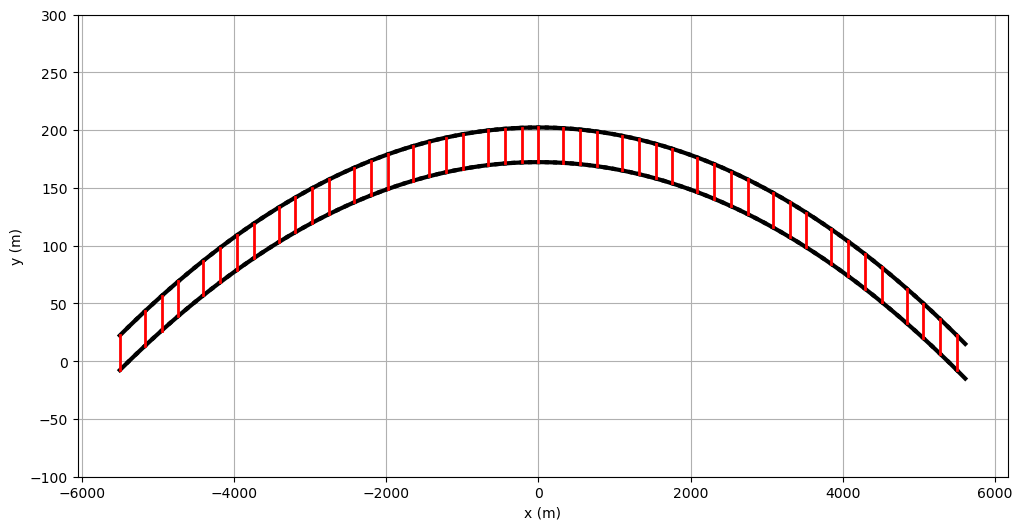

In [163]:
plt.figure(figsize=(12,6))

# -----------------------------
# Plot tunnel arches
# -----------------------------
for ele in Ele_tunnel_1 + Ele_tunnel_2:

    n1 = int(ele[0])
    n2 = int(ele[1])

    x1, y1, _ = NodeC[n1]
    x2, y2, _ = NodeC[n2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        lw=3,
        color='k'
    )

# -----------------------------
# Plot escape routes
# -----------------------------
for ele in Ele_escape:

    n1 = int(ele[0])
    n2 = int(ele[1])

    x1, y1, _ = NodeC[n1]
    x2, y2, _ = NodeC[n2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        lw=2,
        color='r'   # different color helps visualization
    )

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(-100, 300)
plt.grid(True)

plt.xlabel('x (m)')
plt.ylabel('y (m)')

plt.show()

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [164]:
LDOF = 6
nDof = LDOF*nNode  #6 dof per node
K = np.zeros(nDof*nDof)
M = np.zeros(nDof*nDof)
Q = np.zeros(nDof*nDof)

from BeamMatrices import Beam3DMatrices

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(0, nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    
    n1dof = LDOF*n1 + np.arange(0,LDOF)
    n2dof = LDOF*n2 + np.arange(0,LDOF)    
    
    # Calculate elemental matrices
    Me, Ke, Qe = Beam3DMatrices(m, EA, EIy, EIz, GJ, Im, (NodeC[n1], NodeC[n2]) )
    
    indexes = np.append(n1dof, n2dof)
    for i in range(0, 2*LDOF):
        for j in range(0, 2*LDOF):
            ij = indexes[i]*nDof + indexes[j]
            #print(ij)
            M[ij] = M[ij] + Me[i,j]
            K[ij] = K[ij] + Ke[i,j]
            Q[ij] = Q[ij] + Qe[i,j]

# Reshape the global matrix from a 1-dimensional array to a 2-dimensional array
M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))

exeTime[1] = time.time()
print("Execution time = ", exeTime[1] - exeTime[0], "s")

Execution time =  0.07013225555419922 s


That completes the filling of the matrices. Let's have a look at the matrices' structure.

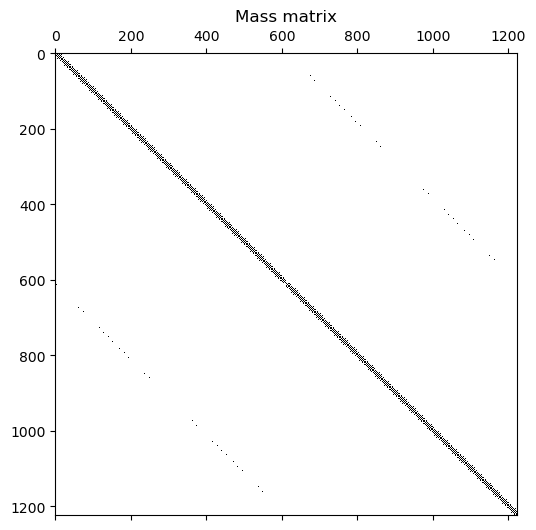

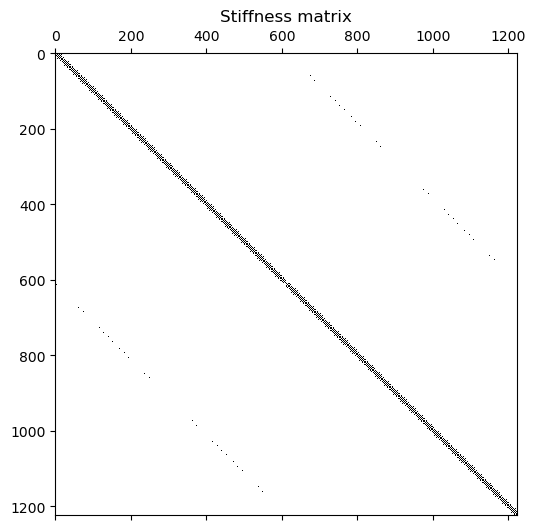

In [165]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
pass

## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

[   0    1    2    3    4    5  606  607  608  609  610  611  612  613
  614  615  616  617 1218 1219 1220 1221 1222 1223]
[   6    7    8 ... 1215 1216 1217]


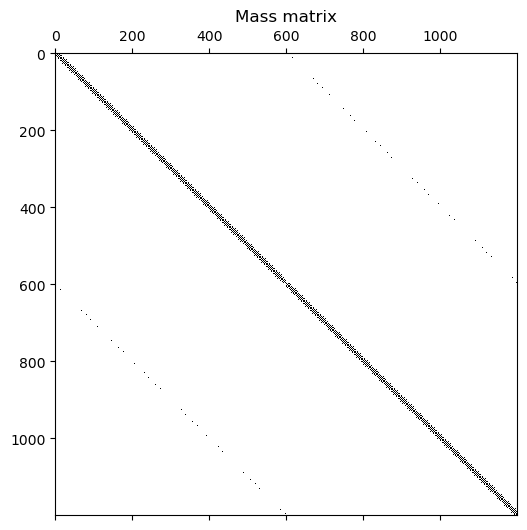

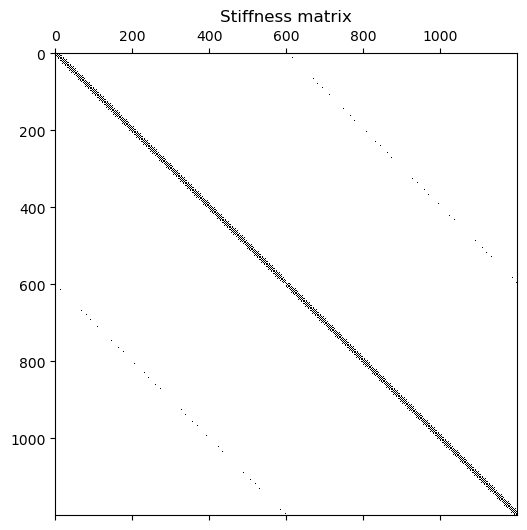

In [166]:
NodesClamp = (0, int(round(nNode/2-1)), int(round(nNode/2)), nNode-1)

# Prescribed dofs
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Free dofs
DofsF = np.arange(0, nDof)       # free DOFs
DofsF = np.delete(DofsF, DofsP)  # remove the fixed DOFs from the free DOFs array

print(DofsP)
print(DofsF)

M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

plt.figure()
plt.spy(M_FF)
plt.title("Mass matrix")
plt.figure()
plt.spy(K_FF)
plt.title("Stiffness matrix")
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [167]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat)
w = np.sqrt(w2.real)
f = w/2/np.pi
print(len(f))

1200


C:\Users\31633\AppData\Local\Temp\ipykernel_70132\367166604.py:3: RuntimeWarning: invalid value encountered in sqrt
  w = np.sqrt(w2.real)


In [168]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

print(f)

[0.00039199 0.00067559 0.00068866 ...        nan        nan        nan]


In [169]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr

1200


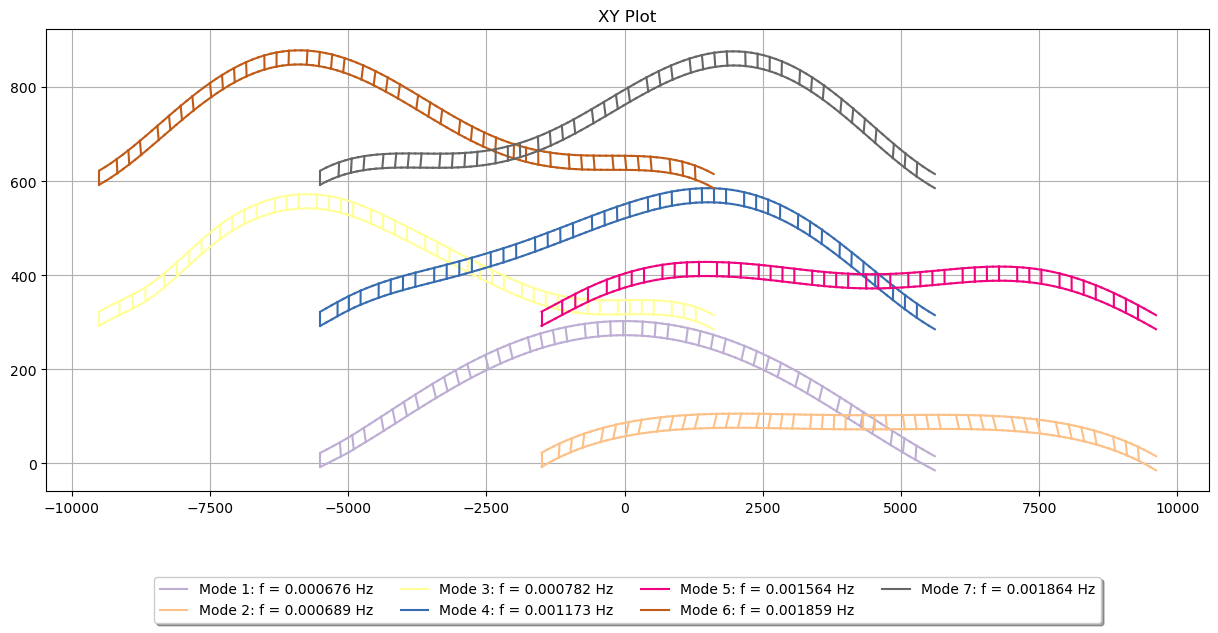

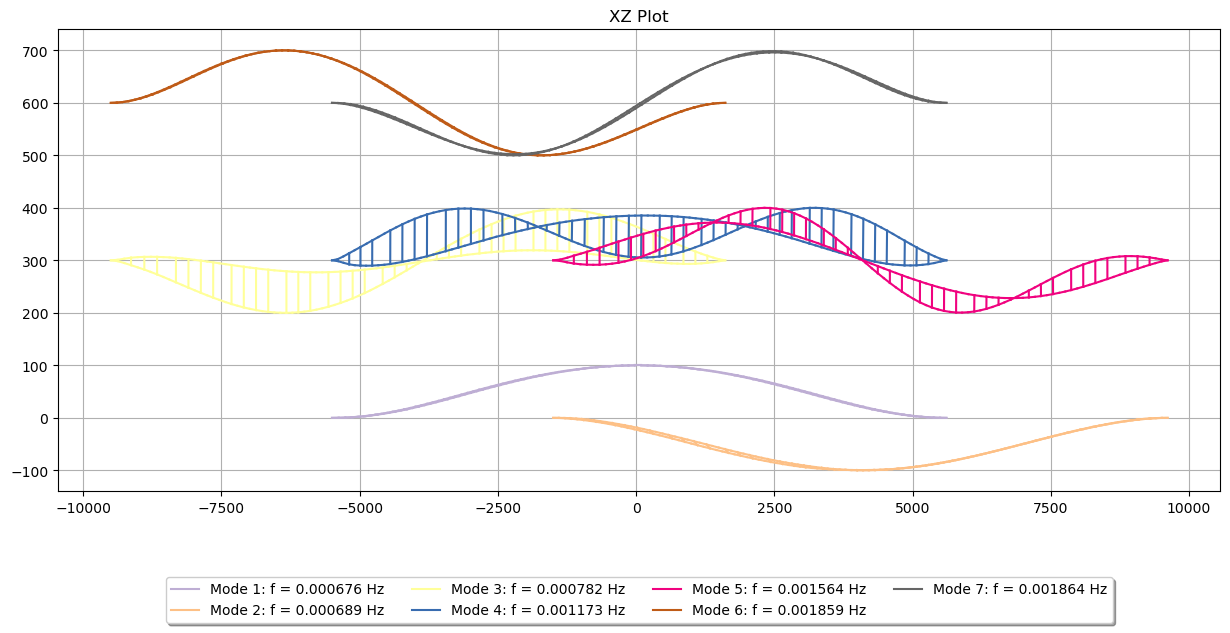

In [170]:
# Plotting mode shapes
plt.figure()
cmap = plt.colormaps.get_cmap('Accent')
cmap = cmap.colors
nCmap = len(cmap)

nCol = 2
nRow = int(np.floor(nMode/nCol))+1

vMode1 = 1
vMode2 = 8

def plotEle(DisplacedNode):
    for iElem in np.arange(0, nEle-1):
        NodeLeft = int(round(Ele[iElem][0]))
        NodeRight = int(round(Ele[iElem][1]))
        if(iElem == 0):
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap], 
                     label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
        else:
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap])


# XY Plot
for iMode in np.arange(vMode1, vMode2):    
    Shape = ModalShape[:, iMode]

    # Scale the mode such that maximum deformation is 10
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

    # Get the deformed shape
    DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF], 
                     [i[1] + 300*np.floor(iMode/3) for i in NodeC] + Shape[1::LDOF])
    
    plotEle(DisplacedNode)
    plt.title("XY Plot")        
    plt.grid('on')
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
          ncol=4, fancybox=True, shadow=True)    


# XZ Plot
plt.figure()
for iMode in np.arange(vMode1, vMode2):    
    Shape = ModalShape[:, iMode]

    # Scale the mode such that maximum deformation is 10
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

    # Get the deformed shape
    DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF],
                     [i[2] + np.floor(iMode/3)*300 for i in NodeC] + Shape[2::LDOF])
    
    plotEle(DisplacedNode)
    plt.title("XZ Plot")    
    plt.grid('on')
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
          ncol=4, fancybox=True, shadow=True)    
    


pass